# 📺 The Simpsons — Análisis de Regresión Lineal
**Pipeline:** PostgreSQL → EDA → Regresión Simple → Regresión Múltiple → VIF → Diagnósticos → Métricas

**Variable objetivo:** `imdb_rating`  
**Predictores:** `viewers_millions`, `season`, `duration_min`, `number_in_season`

---

## 0. Imports y configuración

In [20]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from config.database import engine

os.makedirs("../data/graficas", exist_ok=True)
GRAFICAS = "../data/graficas"

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.3})
sns.set_theme(style="whitegrid", palette="muted")
print("✅ Imports OK")


✅ Imports OK


## 1. Extracción desde PostgreSQL

In [21]:
query_eps = """
    SELECT episode_id, name, season, air_date, number_in_season
    FROM dim_episodes
    ORDER BY episode_id
"""

query_rat = """
    SELECT episode_id, viewers_millions, imdb_rating, duration_min,
           season, number_in_season
    FROM fact_ratings
    ORDER BY episode_id
"""

query_chars = """
    SELECT character_id, name, gender, occupation, status
    FROM dim_characters
"""

df_eps   = pd.read_sql(query_eps,   engine)
df_rat   = pd.read_sql(query_rat,   engine)
df_chars = pd.read_sql(query_chars, engine)

df_eps["air_date"] = pd.to_datetime(df_eps["air_date"], errors="coerce")

print(f"Episodios  : {len(df_eps)}")
print(f"Ratings    : {len(df_rat)}")
print(f"Personajes : {len(df_chars)}")
df_rat.head()


Episodios  : 768
Ratings    : 768
Personajes : 1182


,episode_id,viewers_millions,imdb_rating,duration_min,season,number_in_season
0,1,30.61,7.4,22,1,1
1,2,27.92,8.8,22,1,2
2,3,31.50,8.9,22,1,3
3,4,31.88,8.7,44,1,4
4,5,26.10,8.1,22,1,5


## 2. EDA — Exploración de datos

In [3]:
print("=== Estadísticas descriptivas — Ratings ===")
df_rat[["imdb_rating","viewers_millions","season","duration_min","number_in_season"]].describe().round(2)


=== Estadísticas descriptivas — Ratings ===


,imdb_rating,viewers_millions,season,duration_min,number_in_season
count,768.00,768.00,768.00,768.00,768.00
mean,7.49,18.09,17.91,26.38,11.57
std,0.60,7.31,9.99,8.79,6.47
min,5.60,2.41,1.00,22.00,1.00
25%,7.10,12.09,9.00,22.00,6.00
50%,7.50,18.37,18.00,22.00,11.00
75%,7.90,24.14,27.00,22.00,17.00
max,9.50,33.58,35.00,44.00,25.00


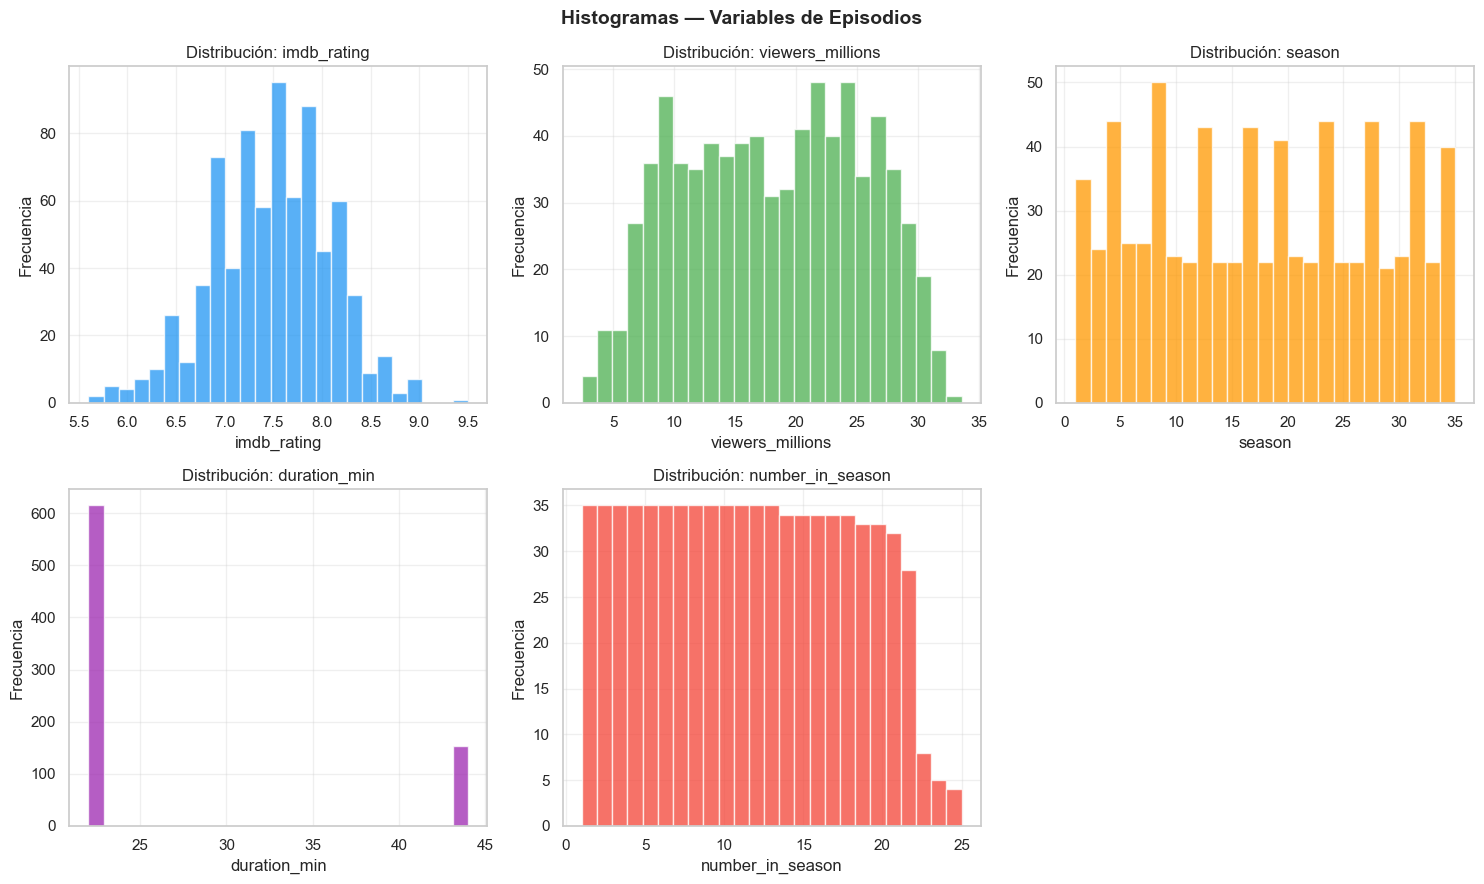

In [4]:
# Histogramas
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
cols_hist = ["imdb_rating","viewers_millions","season","duration_min","number_in_season"]
colors    = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336"]

for ax, col, color in zip(axes.flat, cols_hist, colors):
    ax.hist(df_rat[col].dropna(), bins=25, color=color, alpha=0.75, edgecolor="white")
    ax.set_title(f"Distribución: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")

axes.flat[-1].set_visible(False)
plt.suptitle("Histogramas — Variables de Episodios", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/simpsons_01_histogramas.png", dpi=150, bbox_inches="tight")
plt.show()


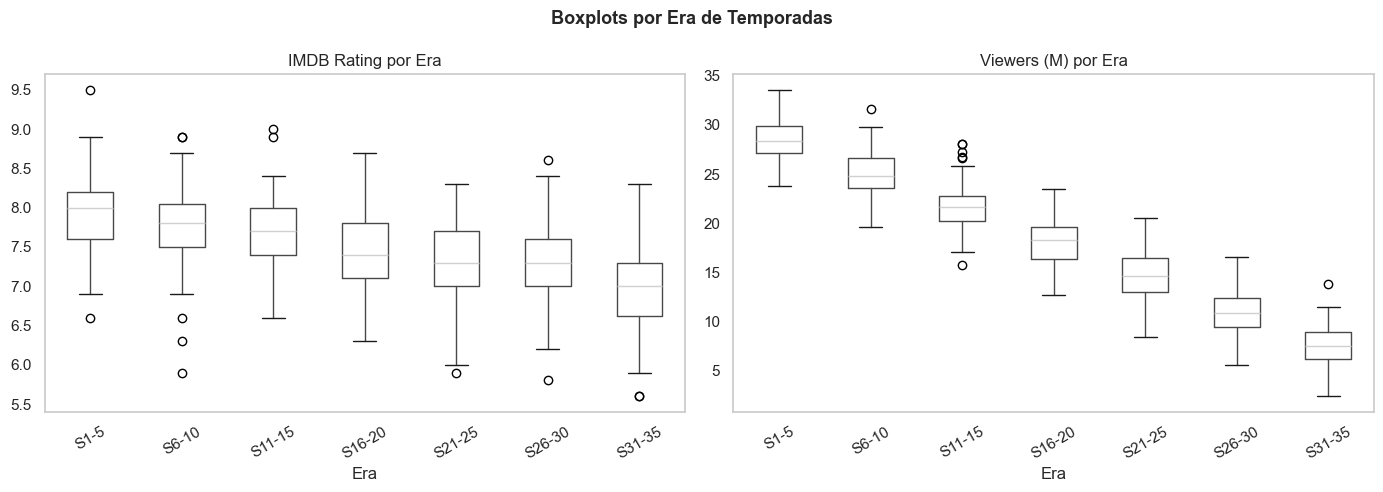

In [5]:
# Boxplots por temporada (agrupadas en bloques de 5)
df_rat["era"] = pd.cut(df_rat["season"], bins=[0,5,10,15,20,25,30,35],
                       labels=["S1-5","S6-10","S11-15","S16-20","S21-25","S26-30","S31-35"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_rat.boxplot(column="imdb_rating",      by="era", ax=axes[0], grid=False)
axes[0].set_title("IMDB Rating por Era")
axes[0].set_xlabel("Era")
axes[0].tick_params(axis="x", rotation=30)

df_rat.boxplot(column="viewers_millions", by="era", ax=axes[1], grid=False)
axes[1].set_title("Viewers (M) por Era")
axes[1].set_xlabel("Era")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Boxplots por Era de Temporadas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/simpsons_02_boxplots_era.png", dpi=150, bbox_inches="tight")
plt.show()


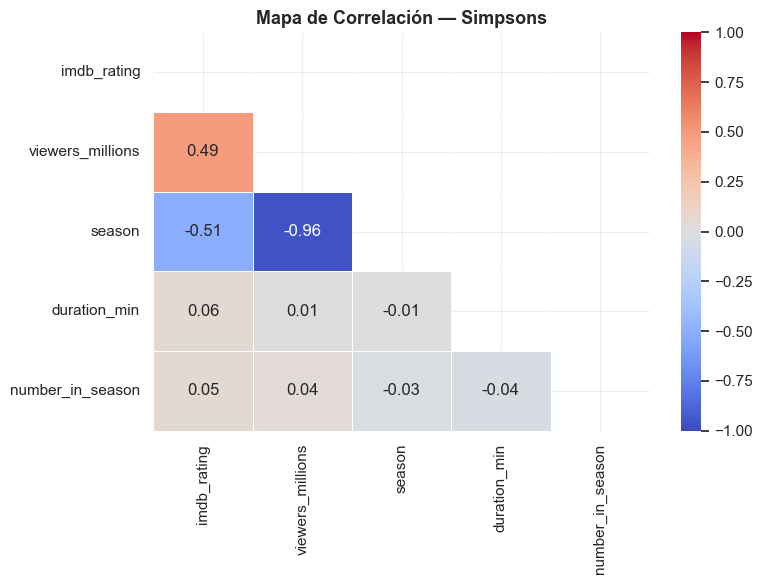

In [6]:
# Mapa de correlación
num_cols = ["imdb_rating","viewers_millions","season","duration_min","number_in_season"]
corr = df_rat[num_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title("Mapa de Correlación — Simpsons", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/simpsons_03_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()


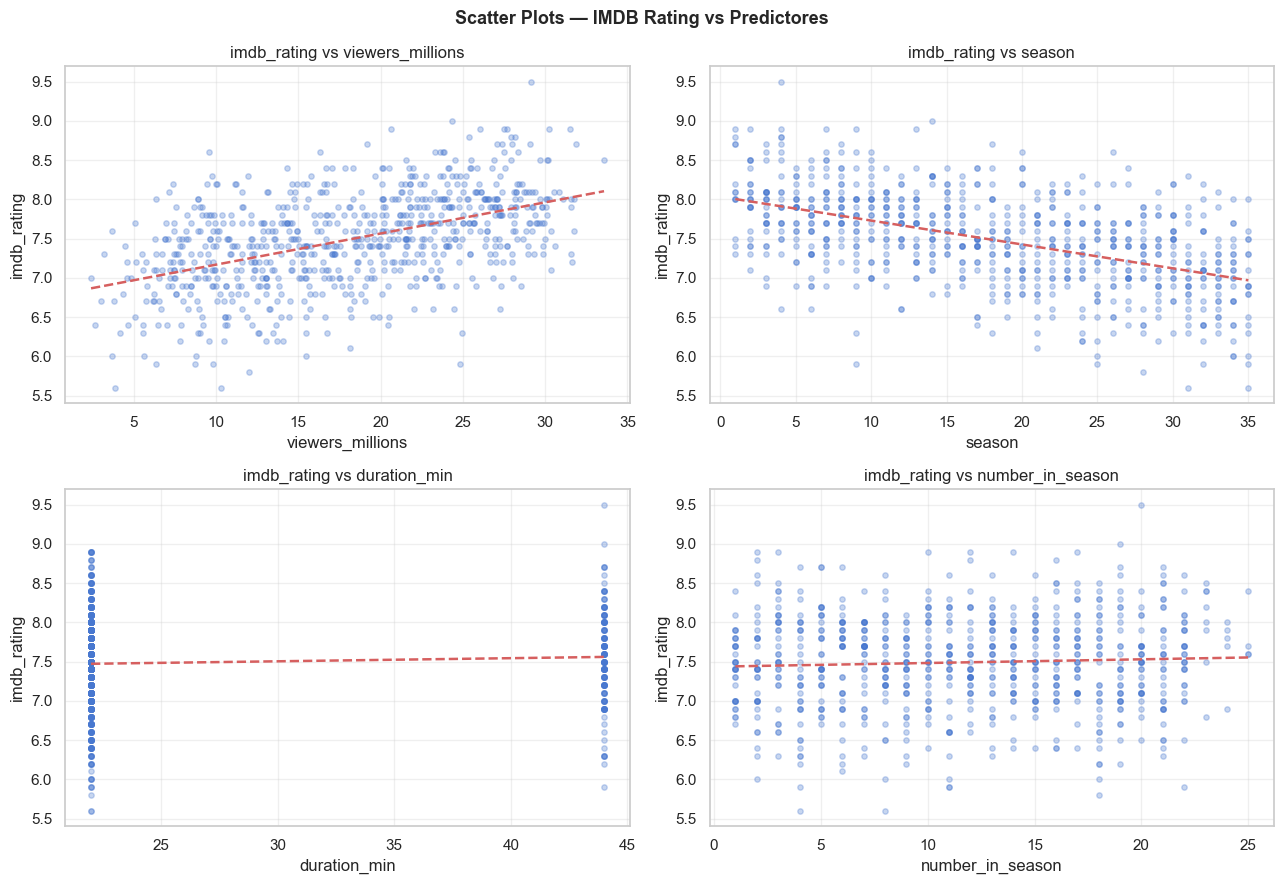

In [7]:
# Scatter plots: imdb_rating vs cada predictor
predictores = ["viewers_millions","season","duration_min","number_in_season"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, pred in zip(axes.flat, predictores):
    ax.scatter(df_rat[pred], df_rat["imdb_rating"], alpha=0.3, s=15)
    m, b = np.polyfit(df_rat[pred].dropna(), df_rat["imdb_rating"].dropna(), 1)
    x_line = np.linspace(df_rat[pred].min(), df_rat[pred].max(), 100)
    ax.plot(x_line, m * x_line + b, "r--", linewidth=1.8)
    ax.set_xlabel(pred)
    ax.set_ylabel("imdb_rating")
    ax.set_title(f"imdb_rating vs {pred}")

plt.suptitle("Scatter Plots — IMDB Rating vs Predictores", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/simpsons_04_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


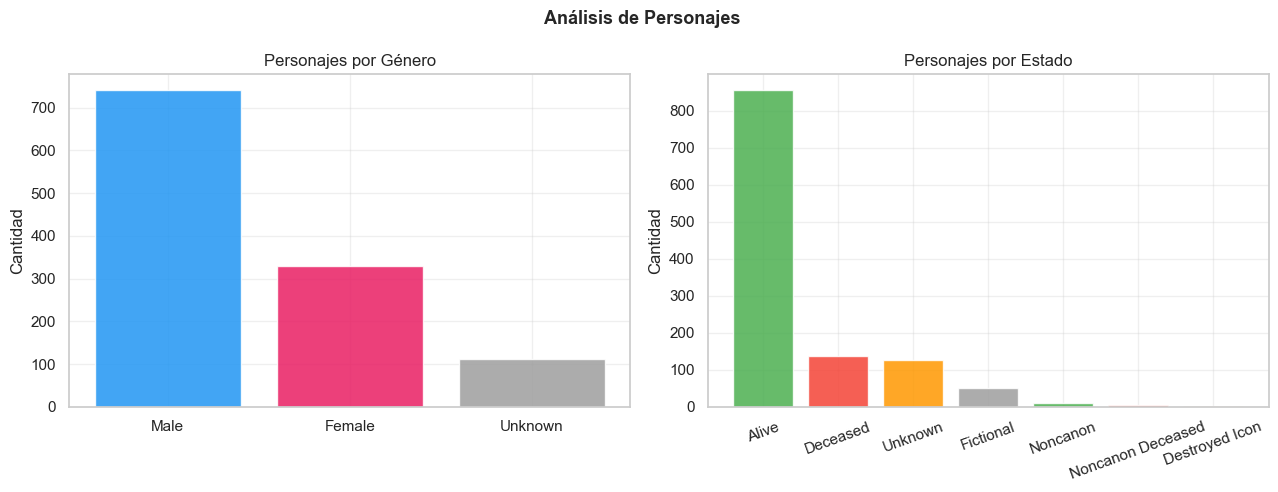

In [8]:
# Distribución de personajes
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

gender_counts = df_chars["gender"].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values,
            color=["#2196F3","#E91E63","#9E9E9E"], alpha=0.85)
axes[0].set_title("Personajes por Género")
axes[0].set_ylabel("Cantidad")

status_counts = df_chars["status"].value_counts()
axes[1].bar(status_counts.index, status_counts.values,
            color=["#4CAF50","#F44336","#FF9800","#9E9E9E"], alpha=0.85)
axes[1].set_title("Personajes por Estado")
axes[1].set_ylabel("Cantidad")
axes[1].tick_params(axis="x", rotation=20)

plt.suptitle("Análisis de Personajes", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/simpsons_05_personajes.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Preparación de datos

In [9]:
FEATURES = ["viewers_millions", "season", "duration_min", "number_in_season"]
TARGET   = "imdb_rating"

df_model = df_rat[FEATURES + [TARGET]].dropna()
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Total registros : {len(df_model)}")
print(f"Train           : {len(X_train)}")
print(f"Test            : {len(X_test)}")


Total registros : 768
Train           : 614
Test            : 154


## 4. Regresión Lineal Simple (mejor predictor)

In [10]:
# Mejor predictor por correlación absoluta con el target
best_pred = df_model[FEATURES].corrwith(y).abs().idxmax()
print(f"Mejor predictor simple: {best_pred}")
print(f"Correlación: {df_model[FEATURES].corrwith(y)[best_pred]:.4f}")

X_simple = sm.add_constant(df_model[[best_pred]])
modelo_simple = sm.OLS(y, X_simple).fit()
print(modelo_simple.summary())


Mejor predictor simple: season
Correlación: -0.5111
                            OLS Regression Results                            
Dep. Variable:            imdb_rating   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     270.8
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           2.52e-52
Time:                        19:19:43   Log-Likelihood:                -574.96
No. Observations:                 768   AIC:                             1154.
Df Residuals:                     766   BIC:                             1163.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


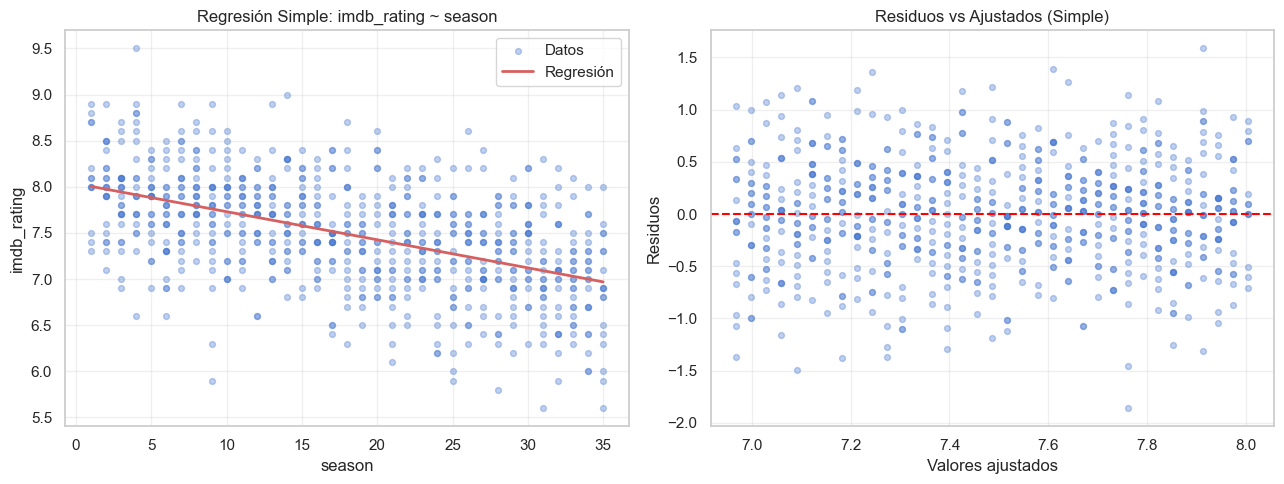

In [11]:
y_pred_simple = modelo_simple.predict(X_simple)
residuos_simple = y - y_pred_simple

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Ajuste
axes[0].scatter(df_model[best_pred], y, alpha=0.35, s=18, label="Datos")
axes[0].plot(df_model[best_pred], y_pred_simple, "r-", linewidth=2, label="Regresión")
axes[0].set_xlabel(best_pred)
axes[0].set_ylabel("imdb_rating")
axes[0].set_title(f"Regresión Simple: imdb_rating ~ {best_pred}")
axes[0].legend()

# Residuos
axes[1].scatter(y_pred_simple, residuos_simple, alpha=0.35, s=18)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Valores ajustados")
axes[1].set_ylabel("Residuos")
axes[1].set_title("Residuos vs Ajustados (Simple)")

plt.tight_layout()
plt.savefig(f"{GRAFICAS}/simpsons_06_regresion_simple.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Regresión Lineal Múltiple

In [12]:
X_mult = sm.add_constant(df_model[FEATURES])
modelo_mult = sm.OLS(y, X_mult).fit()
print(modelo_mult.summary())


                            OLS Regression Results                            
Dep. Variable:            imdb_rating   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.262
Method:                 Least Squares   F-statistic:                     69.12
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           5.99e-50
Time:                        19:19:46   Log-Likelihood:                -572.45
No. Observations:                 768   AIC:                             1155.
Df Residuals:                     763   BIC:                             1178.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                8.0642      0.297  

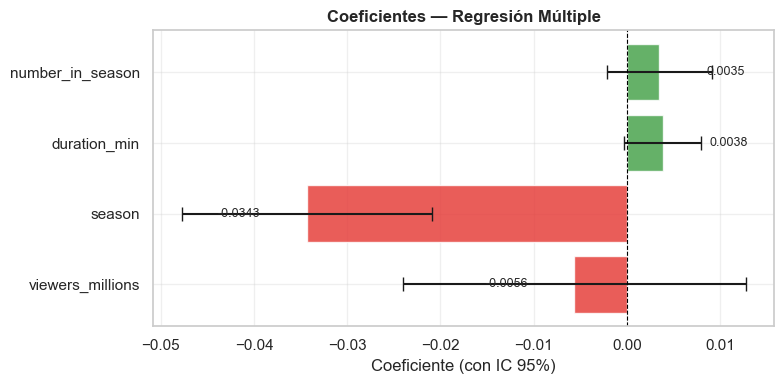

In [13]:
# Visualizar coeficientes con IC 95%
coefs = modelo_mult.params.drop("const")
conf  = modelo_mult.conf_int().drop("const")
err   = conf[1] - coefs

fig, ax = plt.subplots(figsize=(8, 4))
colors_coef = ["#E53935" if v < 0 else "#43A047" for v in coefs]
bars = ax.barh(coefs.index, coefs.values, xerr=err.values,
               color=colors_coef, alpha=0.82, capsize=5)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Coeficiente (con IC 95%)")
ax.set_title("Coeficientes — Regresión Múltiple", fontweight="bold")

for bar, val in zip(bars, coefs.values):
    offset = err[coefs.index[list(coefs).index(val)]] * 1.1 if hasattr(err, "__iter__") else 0.01
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.savefig(f"{GRAFICAS}/simpsons_07_coeficientes.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Cálculo de VIF (Multicolinealidad)

        Variable      VIF        Interpretacion
viewers_millions 6.521538              Moderada
          season 4.340046 Sin multicolinealidad
    duration_min 9.664599              Moderada
number_in_season 4.170998 Sin multicolinealidad


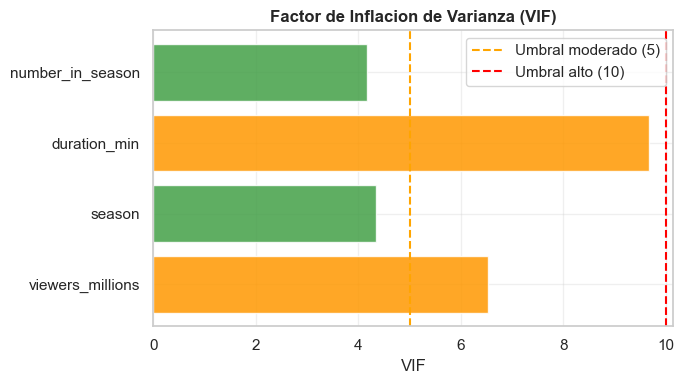

In [14]:
X_vif = df_model[FEATURES].copy()

vif_data = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data["Interpretacion"] = vif_data["VIF"].apply(
    lambda v: "Sin multicolinealidad" if v < 5
    else ("Moderada" if v < 10 else "Alta multicolinealidad")
)
print(vif_data.to_string(index=False))

# Gráfica VIF
fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ["#43A047" if v < 5 else ("#FF9800" if v < 10 else "#E53935")
              for v in vif_data["VIF"]]
ax.barh(vif_data["Variable"], vif_data["VIF"], color=bar_colors, alpha=0.85)
ax.axvline(5,  color="orange", linestyle="--", label="Umbral moderado (5)")
ax.axvline(10, color="red",    linestyle="--", label="Umbral alto (10)")
ax.set_xlabel("VIF")
ax.set_title("Factor de Inflacion de Varianza (VIF)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/simpsons_08_vif.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Diagnósticos visuales y tests estadísticos

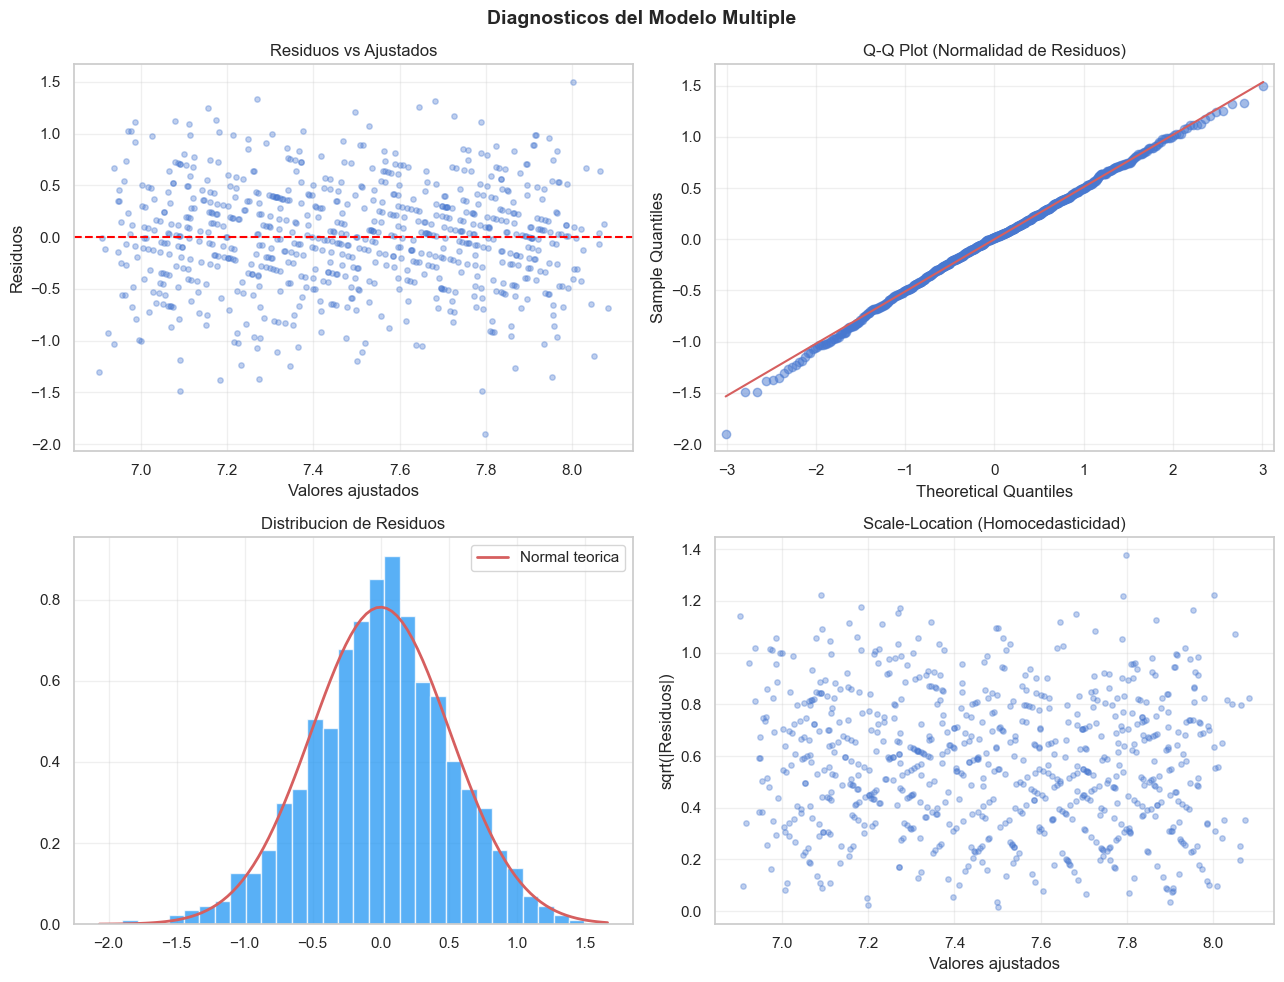

In [15]:
y_pred_mult = modelo_mult.predict(X_mult)
residuos    = modelo_mult.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Residuos vs Ajustados
axes[0,0].scatter(y_pred_mult, residuos, alpha=0.35, s=15)
axes[0,0].axhline(0, color="red", linestyle="--")
axes[0,0].set_xlabel("Valores ajustados")
axes[0,0].set_ylabel("Residuos")
axes[0,0].set_title("Residuos vs Ajustados")

# 2. Q-Q Plot
sm.qqplot(residuos, line="s", ax=axes[0,1], alpha=0.5)
axes[0,1].set_title("Q-Q Plot (Normalidad de Residuos)")

# 3. Histograma de residuos
axes[1,0].hist(residuos, bins=30, color="#2196F3", alpha=0.75,
               edgecolor="white", density=True)
xmin, xmax = axes[1,0].get_xlim()
x_norm = np.linspace(xmin, xmax, 100)
axes[1,0].plot(x_norm, stats.norm.pdf(x_norm, residuos.mean(), residuos.std()),
               "r-", linewidth=2, label="Normal teorica")
axes[1,0].set_title("Distribucion de Residuos")
axes[1,0].legend()

# 4. Scale-Location
sqrt_abs_res = np.sqrt(np.abs(residuos))
axes[1,1].scatter(y_pred_mult, sqrt_abs_res, alpha=0.35, s=15)
axes[1,1].set_xlabel("Valores ajustados")
axes[1,1].set_ylabel("sqrt(|Residuos|)")
axes[1,1].set_title("Scale-Location (Homocedasticidad)")

plt.suptitle("Diagnosticos del Modelo Multiple", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/simpsons_09_diagnosticos.png", dpi=150, bbox_inches="tight")
plt.show()


In [16]:
print("=" * 55)
print("  TESTS ESTADISTICOS")
print("=" * 55)

# Shapiro-Wilk
sample = residuos.sample(min(500, len(residuos)), random_state=42)
stat_sw, p_sw = stats.shapiro(sample)
print(f"\nShapiro-Wilk (normalidad residuos):")
print(f"  W={stat_sw:.4f}  p={p_sw:.4f}  -> {'Normal' if p_sw > 0.05 else 'No normal'}")

# Breusch-Pagan
bp_stat, bp_p, _, _ = het_breuschpagan(residuos, X_mult)
print(f"\nBreusch-Pagan (homocedasticidad):")
print(f"  LM={bp_stat:.4f}  p={bp_p:.4f}  -> {'Homocedasticidad' if bp_p > 0.05 else 'Heterocedasticidad'}")

# Durbin-Watson
dw = durbin_watson(residuos)
print(f"\nDurbin-Watson (autocorrelacion):")
print(f"  DW={dw:.4f}  -> {'Sin autocorrelacion' if 1.5 < dw < 2.5 else 'Posible autocorrelacion'}")
print("=" * 55)


  TESTS ESTADISTICOS

Shapiro-Wilk (normalidad residuos):
  W=0.9977  p=0.7411  -> Normal

Breusch-Pagan (homocedasticidad):
  LM=3.5748  p=0.4666  -> Homocedasticidad

Durbin-Watson (autocorrelacion):
  DW=1.8747  -> Sin autocorrelacion


## 8. Tabla comparativa de métricas

In [17]:
# Modelo simple sklearn
reg_simple = LinearRegression()
reg_simple.fit(X_train[[best_pred]], y_train)
y_pred_s_test = reg_simple.predict(X_test[[best_pred]])
cv_simple = cross_val_score(reg_simple, X[[best_pred]], y, cv=5, scoring="r2")

# Modelo multiple sklearn
reg_mult = LinearRegression()
reg_mult.fit(X_train_sc, y_train)
y_pred_m_test = reg_mult.predict(X_test_sc)
cv_mult = cross_val_score(reg_mult, scaler.fit_transform(X), y, cv=5, scoring="r2")

def metricas_row(y_true, y_pred, cv_scores, sm_model, nombre):
    return {
        "Modelo"  : nombre,
        "R2"      : round(r2_score(y_true, y_pred), 4),
        "R2_CV"   : round(cv_scores.mean(), 4),
        "RMSE"    : round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        "MAE"     : round(mean_absolute_error(y_true, y_pred), 4),
        "R2_adj"  : round(sm_model.rsquared_adj, 4),
        "AIC"     : round(sm_model.aic, 2),
        "BIC"     : round(sm_model.bic, 2),
    }

tabla = pd.DataFrame([
    metricas_row(y_test, y_pred_s_test, cv_simple, modelo_simple, "Simple"),
    metricas_row(y_test, y_pred_m_test, cv_mult,   modelo_mult,   "Multiple"),
])

print("\n" + "=" * 65)
print("  TABLA COMPARATIVA DE METRICAS")
print("=" * 65)
print(tabla.to_string(index=False))
print("=" * 65)
tabla



  TABLA COMPARATIVA DE METRICAS
  Modelo     R2  R2_CV   RMSE    MAE  R2_adj     AIC     BIC
  Simple 0.2623 0.0267 0.5212 0.4004  0.2602 1153.92 1163.20
Multiple 0.2608 0.0195 0.5217 0.3989  0.2621 1154.90 1178.12


,Modelo,R2,R2_CV,RMSE,MAE,R2_adj,AIC,BIC
0,Simple,0.2623,0.0267,0.5212,0.4004,0.2602,1153.92,1163.20
1,Multiple,0.2608,0.0195,0.5217,0.3989,0.2621,1154.90,1178.12


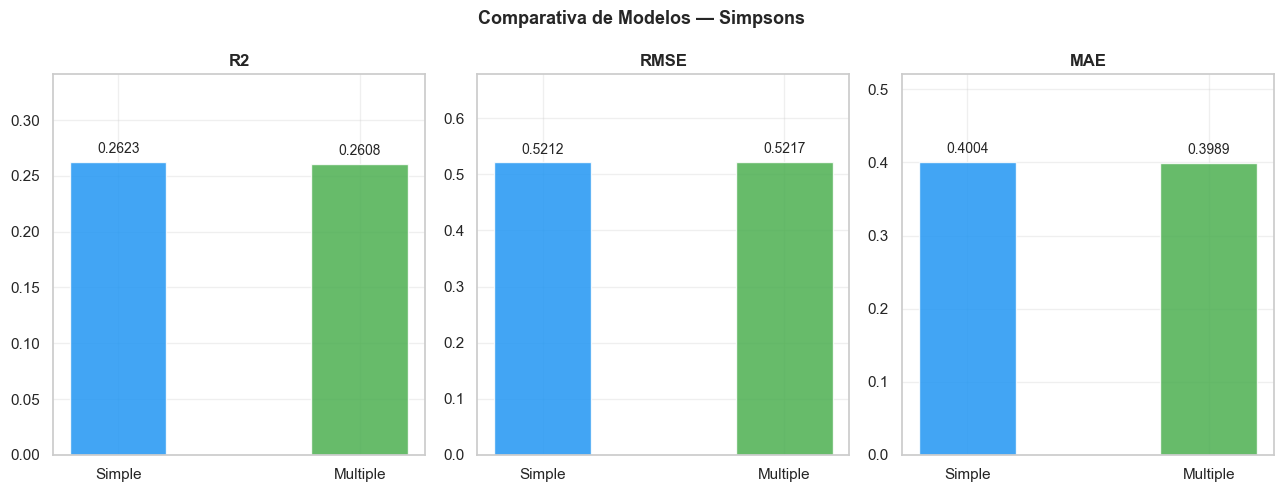


Graficas guardadas en ../data/graficas/


In [18]:
# Grafica comparativa
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
metricas_plot = ["R2", "RMSE", "MAE"]

for ax, met in zip(axes, metricas_plot):
    vals = tabla.set_index("Modelo")[met]
    bars = ax.bar(vals.index, vals.values,
                  color=["#2196F3","#4CAF50"], alpha=0.85, width=0.4)
    ax.set_title(met, fontweight="bold")
    ax.set_ylim(0, vals.max() * 1.3)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + vals.max() * 0.03,
                f"{val:.4f}", ha="center", fontsize=10)

plt.suptitle("Comparativa de Modelos — Simpsons", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/simpsons_10_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nGraficas guardadas en {GRAFICAS}/")
